Task1 - Regression Techniques

1. Load a dataset (e.g., Boston Housing or any housing dataset) and build a simple linear regression model to predict house prices based on one independent variable (e.g., square footage).

2. Plot the regression line and interpret the slope.

3. Use multiple linear regression on the same dataset to include additional features like number of rooms and age of the house.

4. Evaluate model performance using R² and RMSE.

5. Compare the performance of simple vs multiple regression models and explain which performs better and why.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv('BostonHousing.csv')

1. Load a dataset (e.g., Boston Housing or any housing dataset) and build a simple linear regression model to predict house prices based on one independent variable (e.g., square footage).

In [46]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4,0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6,0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9,0
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0,0


## Simple linear regression using AGE feature to train

In [47]:
X= df["AGE"]
y = df["MEDV"]

In [48]:
from sklearn.model_selection import train_test_split
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X, y, test_size = 0.25, random_state=32)

In [49]:
from sklearn.linear_model import LinearRegression
l_r = LinearRegression()
l_r.fit(X_train_simple.values.reshape(-1,1), y_train_simple)
y_pred_train_simple = l_r.predict(X_train_simple.values.reshape(-1,1))
y_pred_test_simple = l_r.predict(X_test_simple.values.reshape(-1,1))
score_simple = l_r.score(X_test_simple.values.reshape(-1,1), y_test_simple)
score_simple

0.10174866484450895

In [52]:
rmse_simple2 = root_mean_squared_error(y_test_simple, y_pred_test_simple)
rmse_simple2

9.006704725081415

## 2. Plot the regression line and interpret the slope.


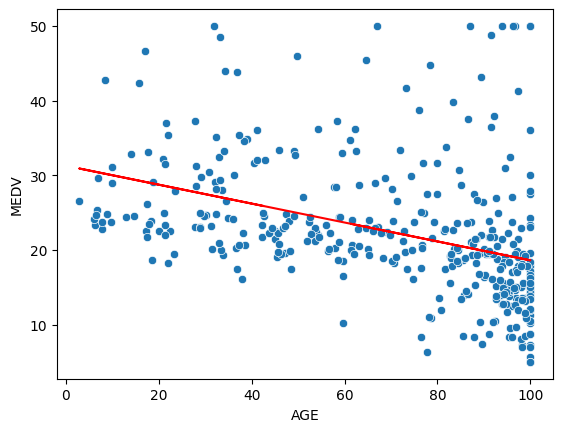

In [ ]:
sns.scatterplot(x = X_train_simple, y = y_train_simple)
plt.plot(X_train_simple, y_pred_train_simple, color = "red")

3. Use multiple linear regression on the same dataset to include additional features like number of rooms and age of the house.

In [ ]:
df.shape

(506, 14)

In [ ]:
# checking any columns with null values
df.loc[:, df.isnull().any()].isnull().sum()

,0


In [ ]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4,0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6,0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9,0
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0,0


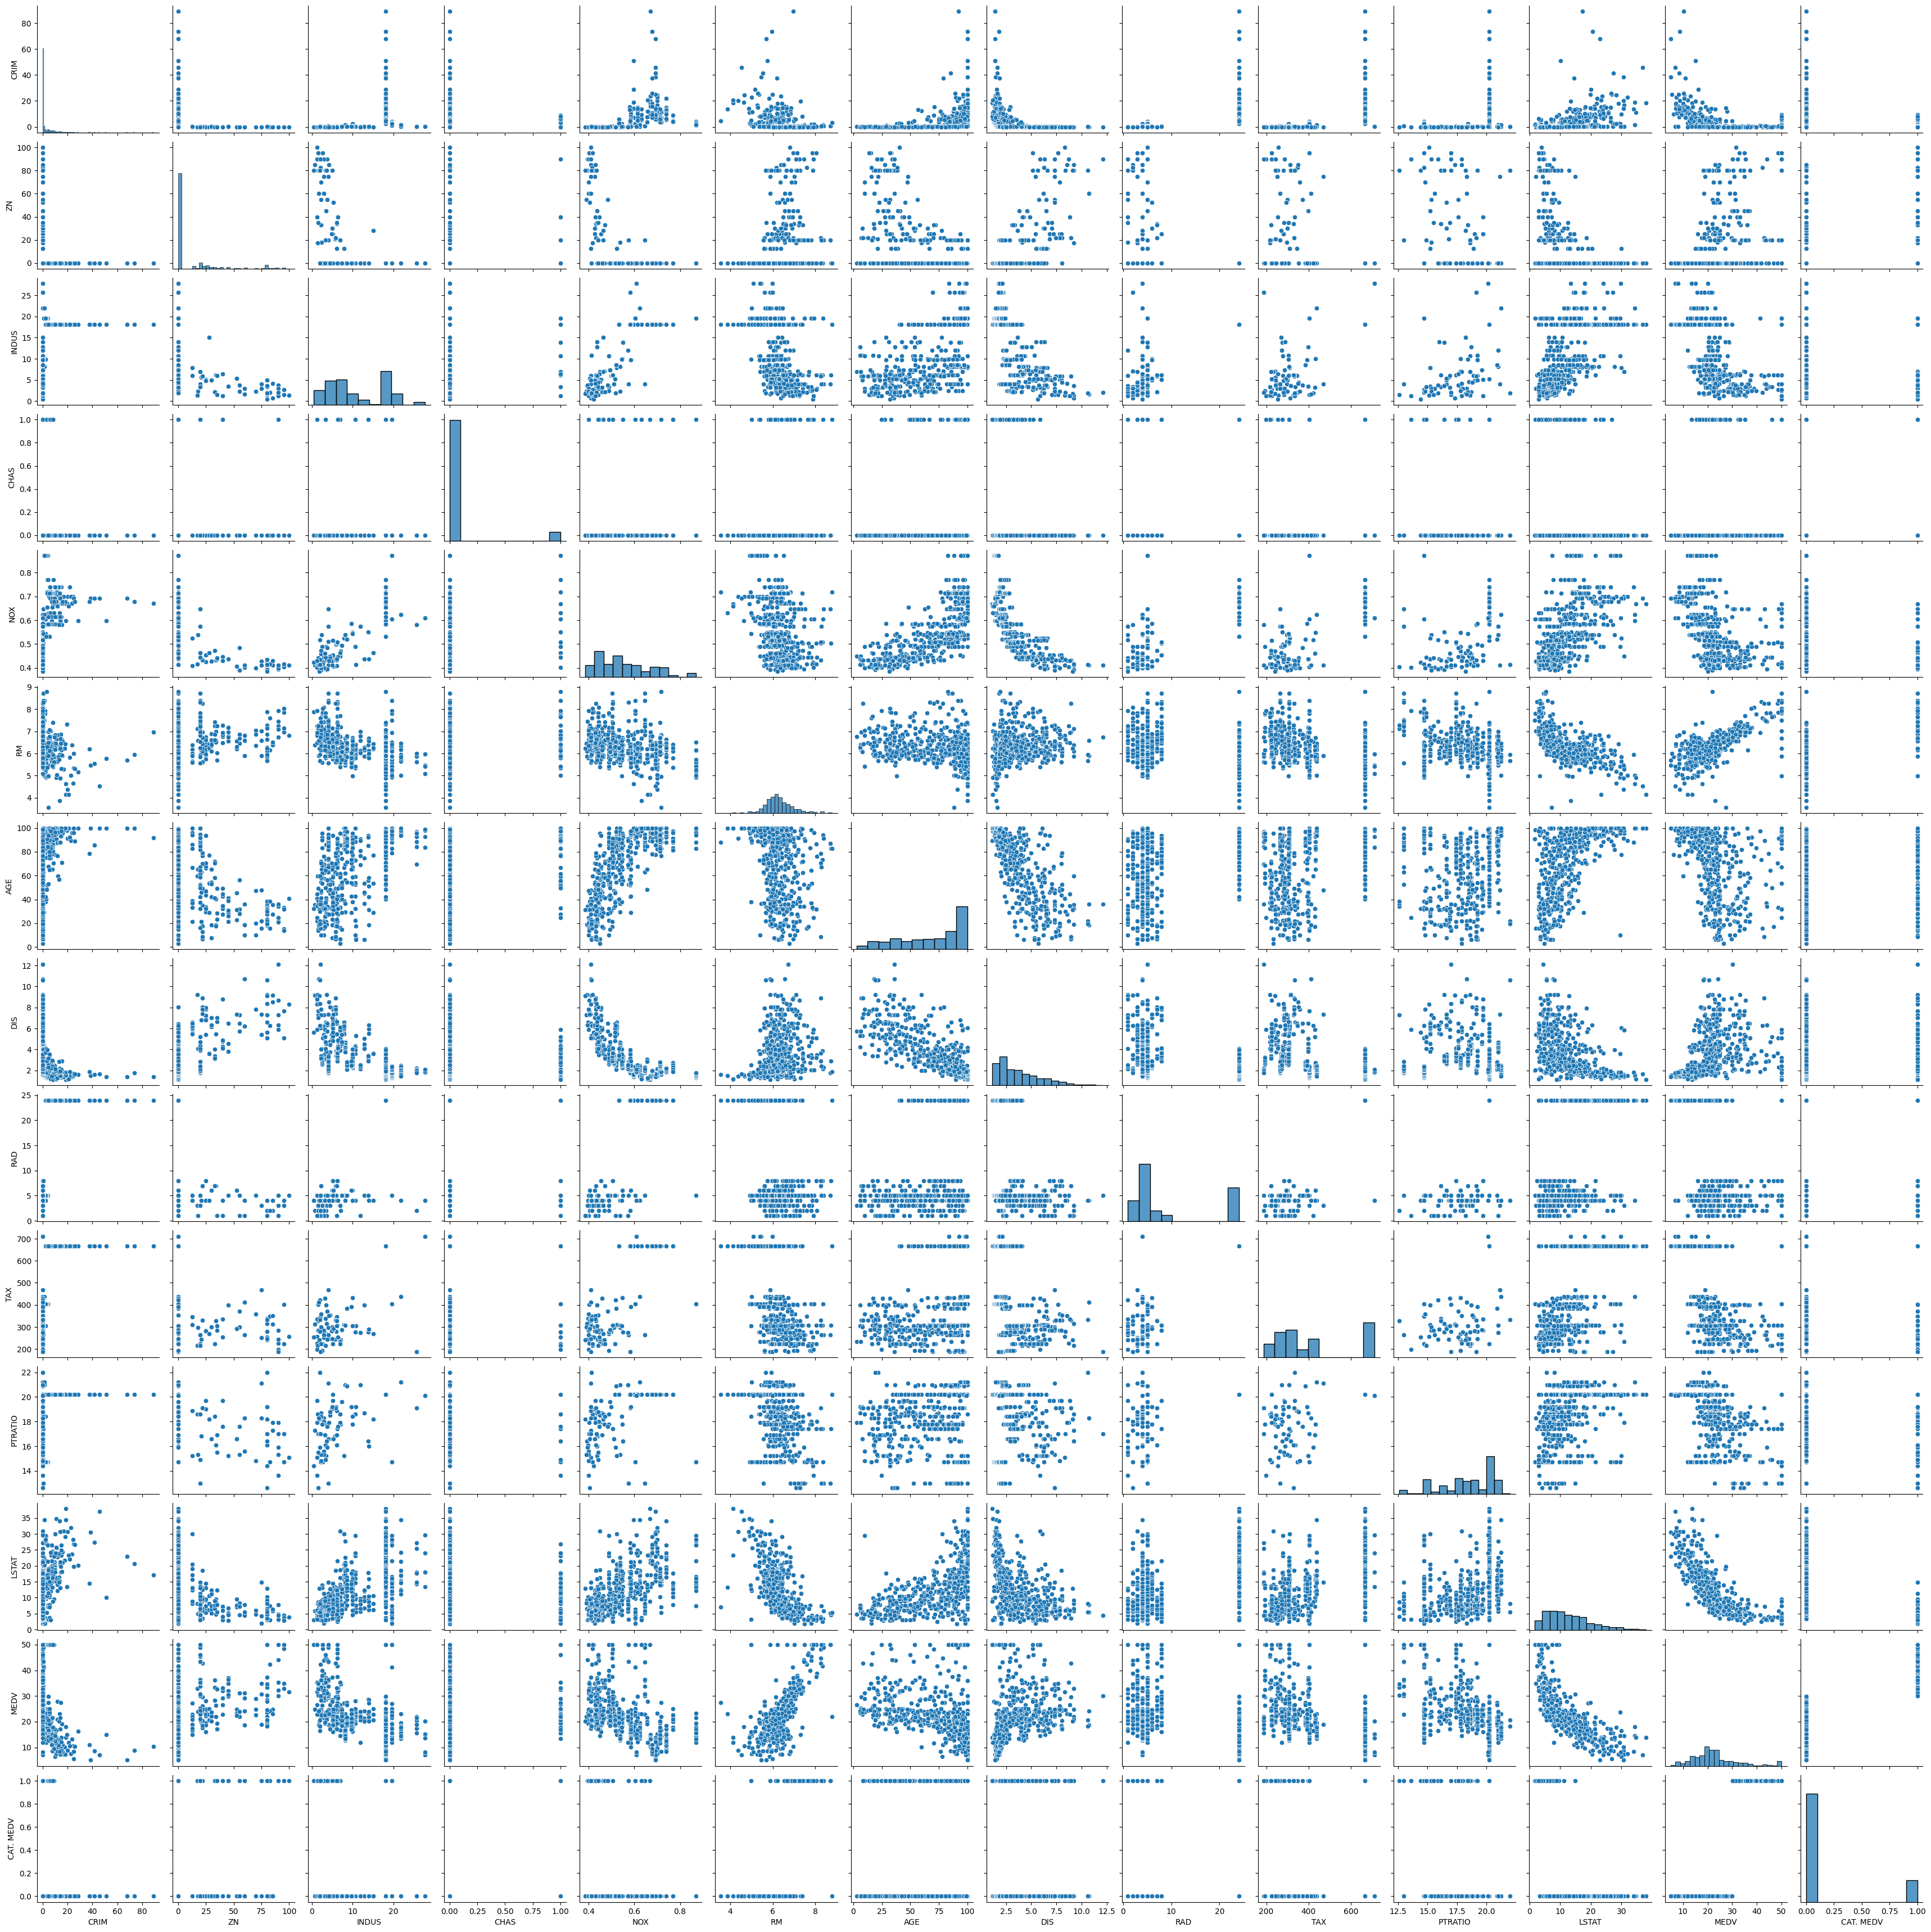

In [ ]:
sns.pairplot(df)

In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,CAT. MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806,0.166008
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104,0.372456
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000,0.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000,0.000000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000,0.000000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000,0.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000,1.000000


<Axes: >

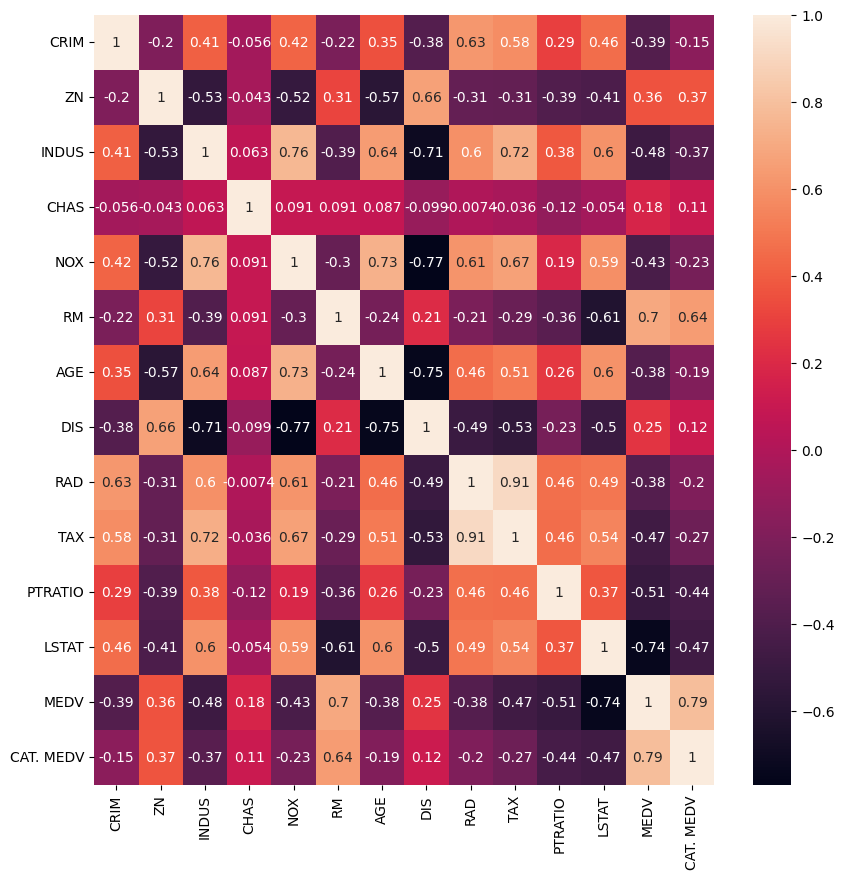

In [ ]:
plt.figure(figsize = (10,10))
sns.heatmap(df.corr(), annot = True)

In [ ]:
def correlation (dataset, threshold):
    col_corr= set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
              colname = corr_matrix.columns [i]
              col_corr.add(colname)

    return col_corr

In [ ]:
correlation(df, 0.8)

{'TAX'}

In [ ]:
df = df.drop(correlation(df, 0.8), axis=1)
df.shape

(506, 13)

In [ ]:
df["CHAS"].value_counts()

,count
CHAS,
0,471
1,35


In [ ]:
# Dropping CHAS column as its freq is highly skewed- 90% same value
df = df.drop(columns = ["CHAS"], axis =1)
df

,INDUS,NOX,RM,AGE,DIS,RAD,PTRATIO,LSTAT,MEDV,ZN_bin,Log_CRIM
0,2.31,0.538,6.575,65.2,4.0900,1,15.3,4.98,24.0,1,0.006300
1,7.07,0.469,6.421,78.9,4.9671,2,17.8,9.14,21.6,0,0.026944
2,7.07,0.469,7.185,61.1,4.9671,2,17.8,4.03,34.7,0,0.026924
3,2.18,0.458,6.998,45.8,6.0622,3,18.7,2.94,33.4,0,0.031857
4,2.18,0.458,7.147,54.2,6.0622,3,18.7,5.33,36.2,0,0.066770
...,...,...,...,...,...,...,...,...,...,...,...
501,11.93,0.573,6.593,69.1,2.4786,1,21.0,9.67,22.4,0,0.060747
502,11.93,0.573,6.120,76.7,2.2875,1,21.0,9.08,20.6,0,0.044275
503,11.93,0.573,6.976,91.0,2.1675,1,21.0,5.64,23.9,0,0.058986
504,11.93,0.573,6.794,89.3,2.3889,1,21.0,6.48,22.0,0,0.103991


## Outlier detection and handling

In [ ]:
outlier_count = {}

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_count = pd.Series(outlier_count).sort_values(ascending=False)
print("Outlier count per column:\n", outlier_count)

Outlier count per column:
 CAT. MEDV    84
ZN           68
CRIM         66
MEDV         40
CHAS         35
RM           30
PTRATIO      15
LSTAT         7
DIS           5
NOX           0
INDUS         0
RAD           0
AGE           0
dtype: int64


<Axes: xlabel='ZN', ylabel='Count'>

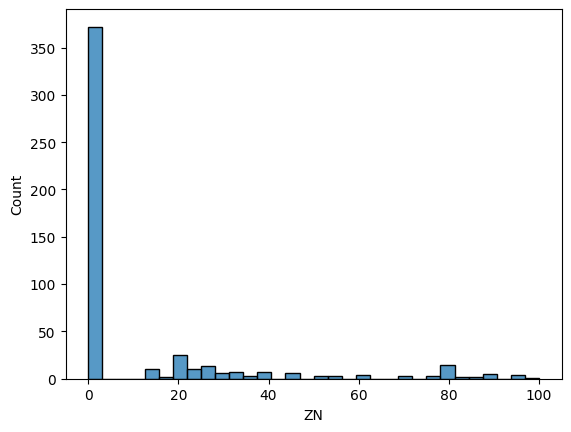

In [ ]:
sns.histplot(df["ZN"])

<Axes: xlabel='Log_ZN', ylabel='Count'>

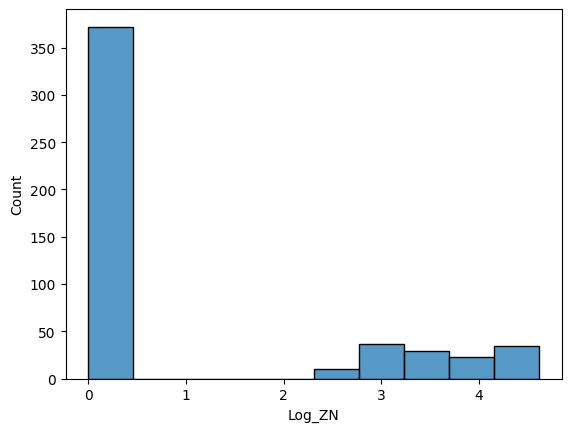

In [ ]:
# Log trnsform of ZN column
df["Log_ZN"] = np.log1p(df["ZN"])
sns.histplot(df["Log_ZN"])

In [ ]:
df["ZN"].value_counts()

,count
ZN,
0.0,372
20.0,21
80.0,15
22.0,10
25.0,10
12.5,10
40.0,7
30.0,6
45.0,6


In [ ]:
df["Log_ZN"].value_counts()

,count
Log_ZN,
0.000000,372
3.044522,21
4.394449,15
3.135494,10
3.258097,10
2.602690,10
3.713572,7
3.433987,6
3.828641,6


In [ ]:
df['ZN_bin'] = pd.qcut(df['ZN'], q=4, labels=False, duplicates='drop')

In [ ]:
df['ZN_bin'].value_counts()

,count
ZN_bin,
0,382
1,124


<Axes: xlabel='ZN_bin', ylabel='Count'>

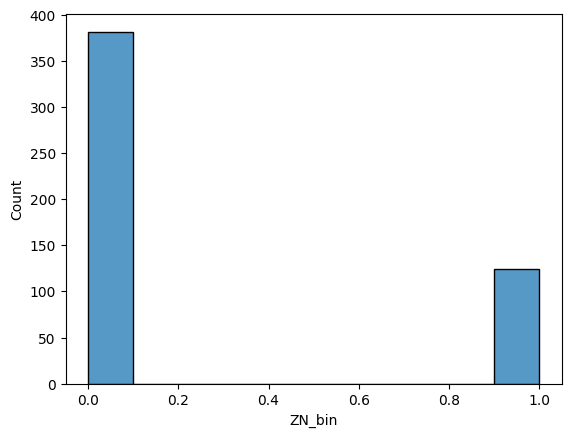

In [ ]:
sns.histplot(df["ZN_bin"])

In [ ]:
df

,INDUS,NOX,RM,AGE,DIS,RAD,PTRATIO,LSTAT,MEDV,ZN_bin,Log_CRIM
0,2.31,0.538,6.575,65.2,4.0900,1,15.3,4.98,24.0,1,0.006300
1,7.07,0.469,6.421,78.9,4.9671,2,17.8,9.14,21.6,0,0.026944
2,7.07,0.469,7.185,61.1,4.9671,2,17.8,4.03,34.7,0,0.026924
3,2.18,0.458,6.998,45.8,6.0622,3,18.7,2.94,33.4,0,0.031857
4,2.18,0.458,7.147,54.2,6.0622,3,18.7,5.33,36.2,0,0.066770
...,...,...,...,...,...,...,...,...,...,...,...
501,11.93,0.573,6.593,69.1,2.4786,1,21.0,9.67,22.4,0,0.060747
502,11.93,0.573,6.120,76.7,2.2875,1,21.0,9.08,20.6,0,0.044275
503,11.93,0.573,6.976,91.0,2.1675,1,21.0,5.64,23.9,0,0.058986
504,11.93,0.573,6.794,89.3,2.3889,1,21.0,6.48,22.0,0,0.103991


In [ ]:
#CAT.MEDV and MEDV - are correlated- CAT.MEDV is 1 for >30 MEDV. SO, droping that column
df = df.drop(columns = ["CAT. MEDV", "Log_ZN", "ZN"], axis =1)
df


,CRIM,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,LSTAT,MEDV,ZN_bin
0,0.00632,2.31,0,0.538,6.575,65.2,4.0900,1,15.3,4.98,24.0,1
1,0.02731,7.07,0,0.469,6.421,78.9,4.9671,2,17.8,9.14,21.6,0
2,0.02729,7.07,0,0.469,7.185,61.1,4.9671,2,17.8,4.03,34.7,0
3,0.03237,2.18,0,0.458,6.998,45.8,6.0622,3,18.7,2.94,33.4,0
4,0.06905,2.18,0,0.458,7.147,54.2,6.0622,3,18.7,5.33,36.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,11.93,0,0.573,6.593,69.1,2.4786,1,21.0,9.67,22.4,0
502,0.04527,11.93,0,0.573,6.120,76.7,2.2875,1,21.0,9.08,20.6,0
503,0.06076,11.93,0,0.573,6.976,91.0,2.1675,1,21.0,5.64,23.9,0
504,0.10959,11.93,0,0.573,6.794,89.3,2.3889,1,21.0,6.48,22.0,0


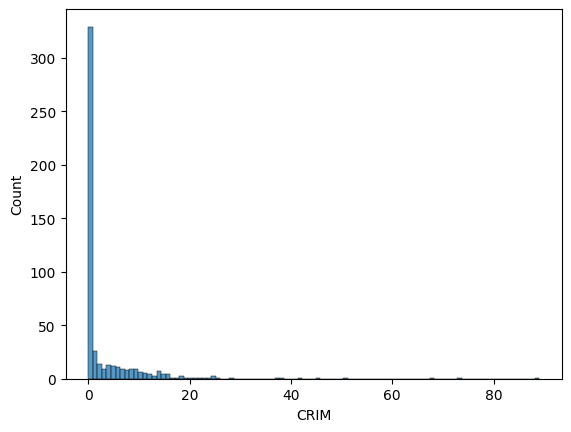

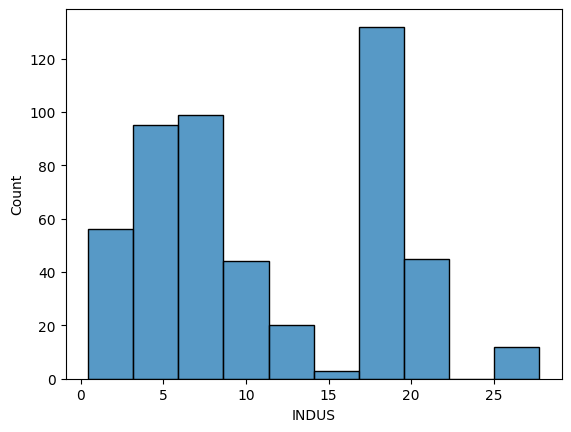

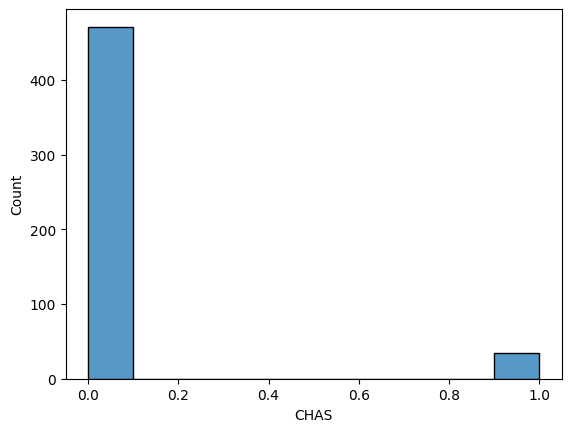

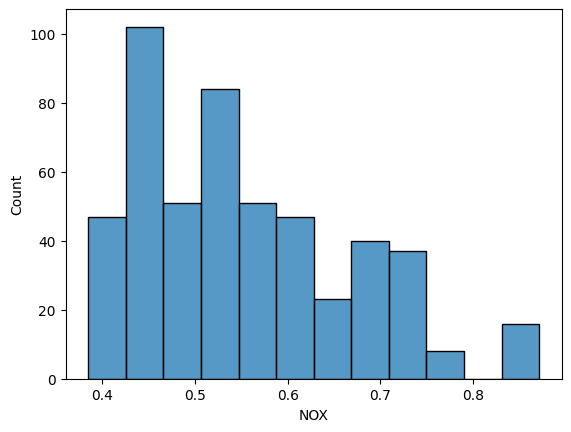

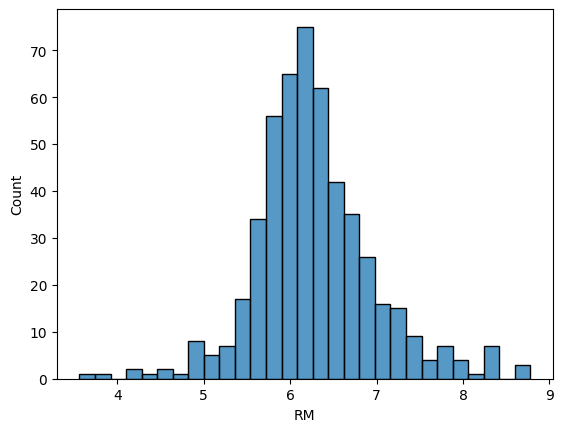

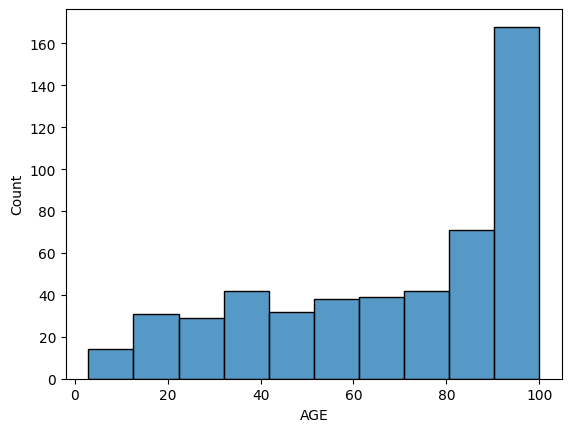

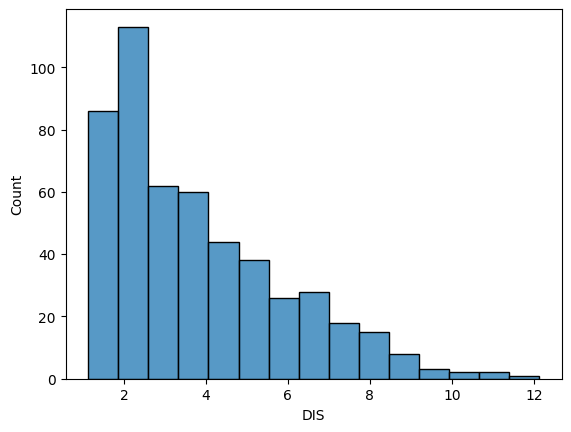

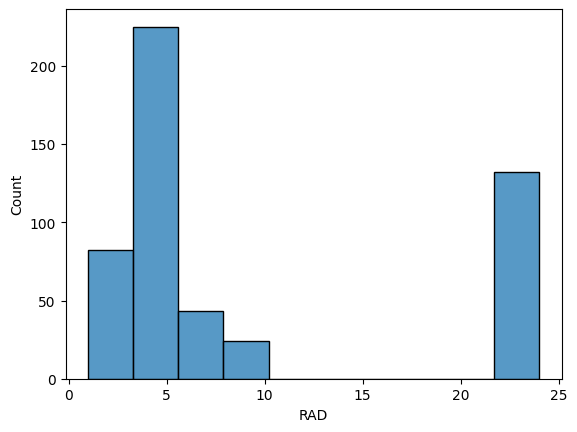

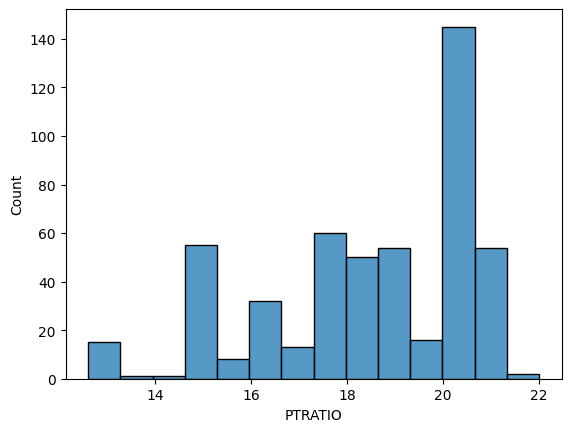

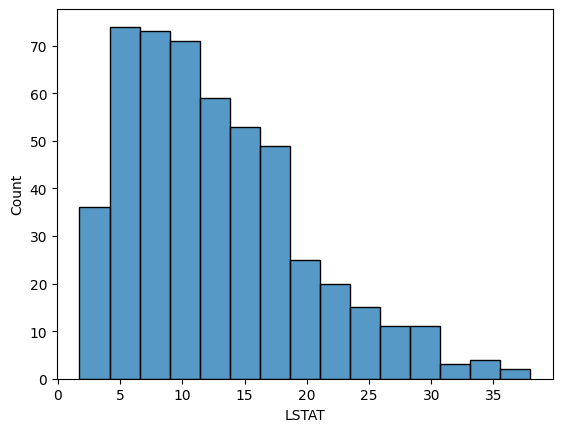

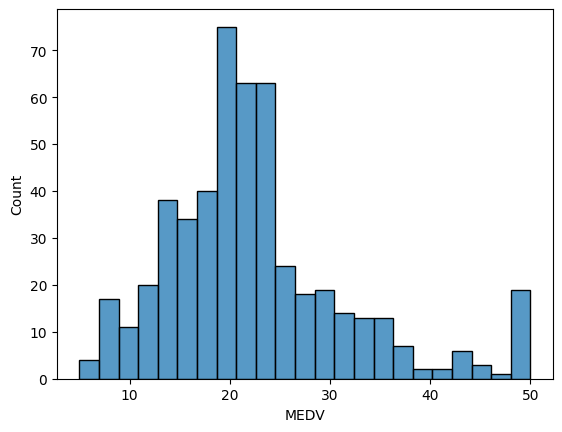

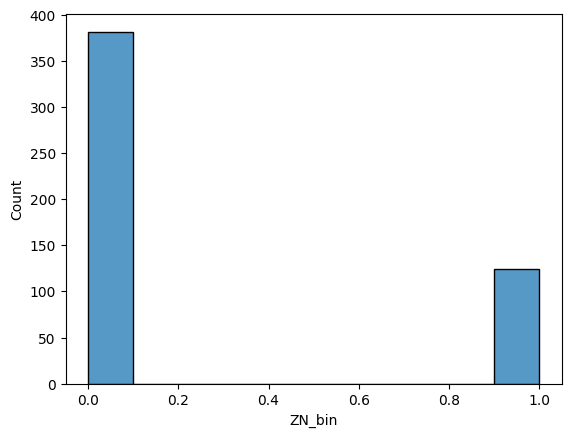

In [ ]:
#plotting histplot for all columns
for col in df.columns:
    sns.histplot(df[col])
    plt.show()

<Axes: xlabel='Log_CRIM', ylabel='Count'>

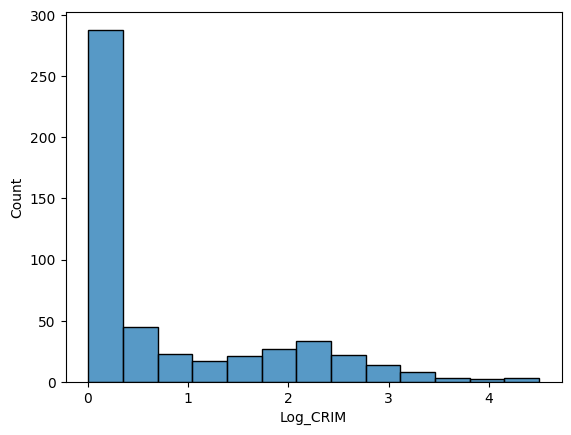

In [ ]:
# for CRIM column, log transform to normalize
df["Log_CRIM"] = np.log1p(df["CRIM"])
sns.histplot(df["Log_CRIM"])

<Axes: xlabel='Log_AGE', ylabel='Count'>

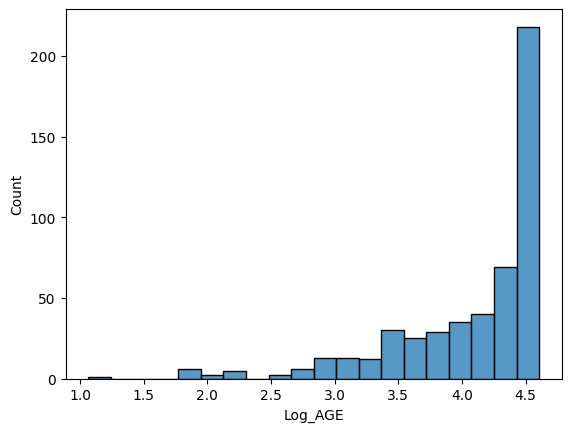

In [ ]:
# for Age, applying log transform
df["Log_AGE"] = np.log(df["AGE"])
sns.histplot(df["Log_AGE"])

## Log transform for left skewed data is not good, so applying standard scaler similar to all column will do good
## other columns are close to normal

In [ ]:
df = df.drop(columns = ["Log_AGE", "CRIM"], axis =1)
df

,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,LSTAT,MEDV,ZN_bin,Log_CRIM
0,2.31,0,0.538,6.575,65.2,4.0900,1,15.3,4.98,24.0,1,0.006300
1,7.07,0,0.469,6.421,78.9,4.9671,2,17.8,9.14,21.6,0,0.026944
2,7.07,0,0.469,7.185,61.1,4.9671,2,17.8,4.03,34.7,0,0.026924
3,2.18,0,0.458,6.998,45.8,6.0622,3,18.7,2.94,33.4,0,0.031857
4,2.18,0,0.458,7.147,54.2,6.0622,3,18.7,5.33,36.2,0,0.066770
...,...,...,...,...,...,...,...,...,...,...,...,...
501,11.93,0,0.573,6.593,69.1,2.4786,1,21.0,9.67,22.4,0,0.060747
502,11.93,0,0.573,6.120,76.7,2.2875,1,21.0,9.08,20.6,0,0.044275
503,11.93,0,0.573,6.976,91.0,2.1675,1,21.0,5.64,23.9,0,0.058986
504,11.93,0,0.573,6.794,89.3,2.3889,1,21.0,6.48,22.0,0,0.103991


In [ ]:
outlier_count = {}

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_count = pd.Series(outlier_count).sort_values(ascending=False)
print("Outlier count per column:\n", outlier_count)

Outlier count per column:
 ZN_bin      124
MEDV         40
RM           30
PTRATIO      15
LSTAT         7
Log_CRIM      6
DIS           5
NOX           0
INDUS         0
RAD           0
AGE           0
dtype: int64


## for ZN_bin outlier is handled during standardscaling
## MEDV is target, trying robustscaler- scale by median unlike stdscaler
## CHAS, RM, PTRATIO, LSTAT, Log_CRIM, DIS- trying capping it with IQR

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

<Axes: xlabel='MEDV', ylabel='Count'>

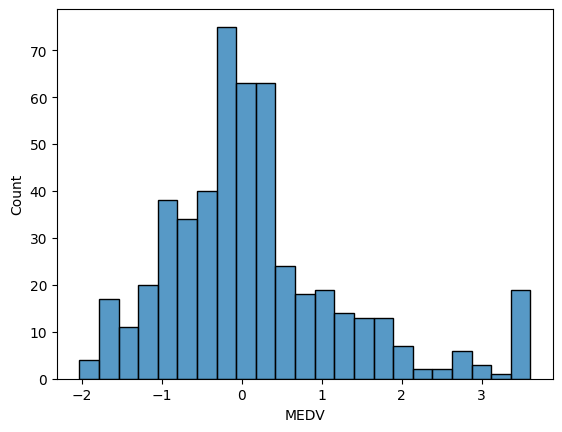

In [ ]:
sns.histplot(df_scaled["MEDV"])
## robust scaling is not helping as its outliers are not too far

<Figure size 1200x800 with 0 Axes>

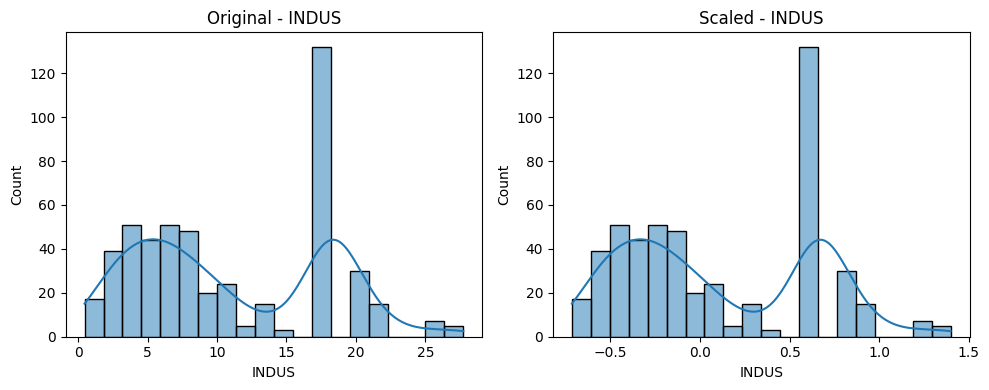

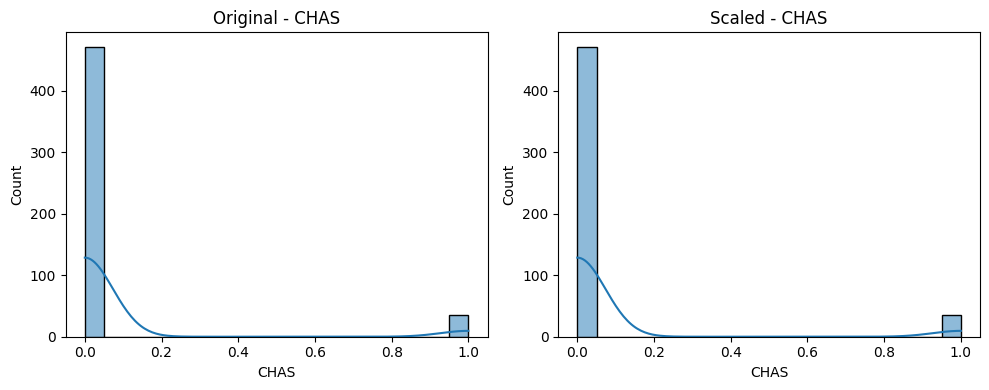

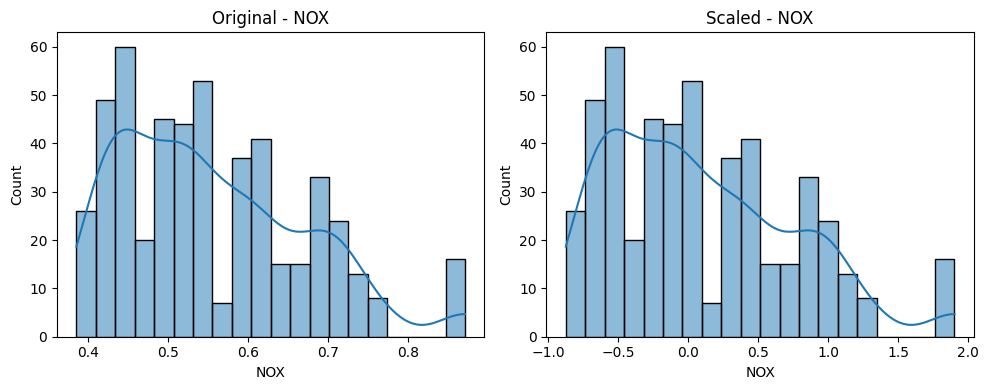

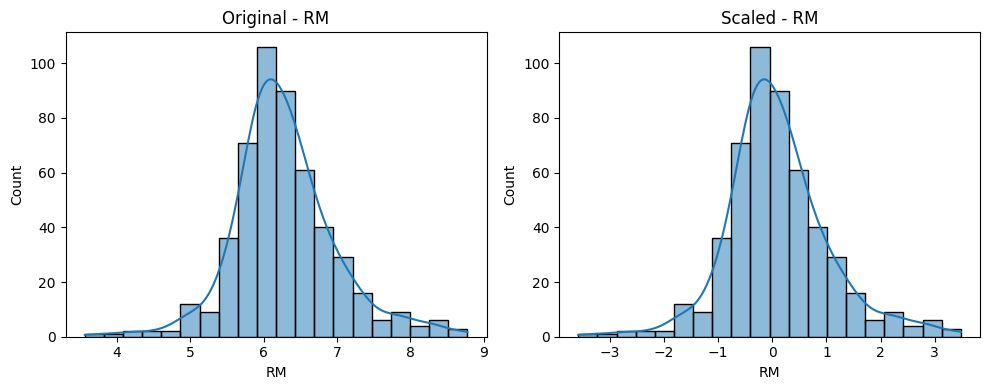

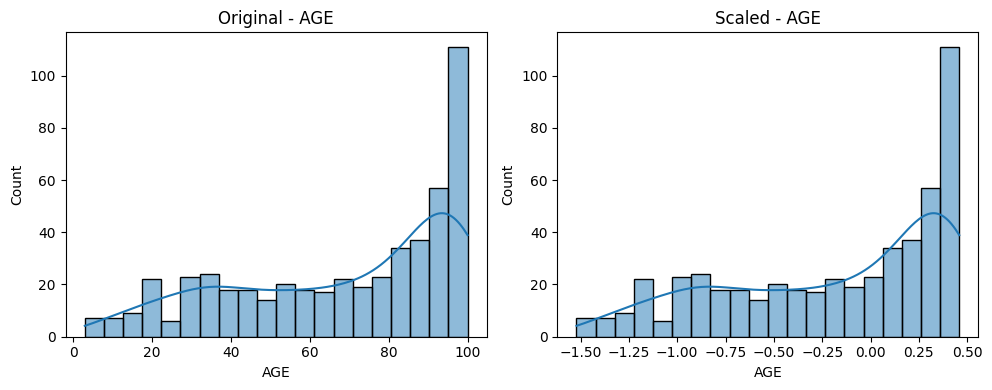

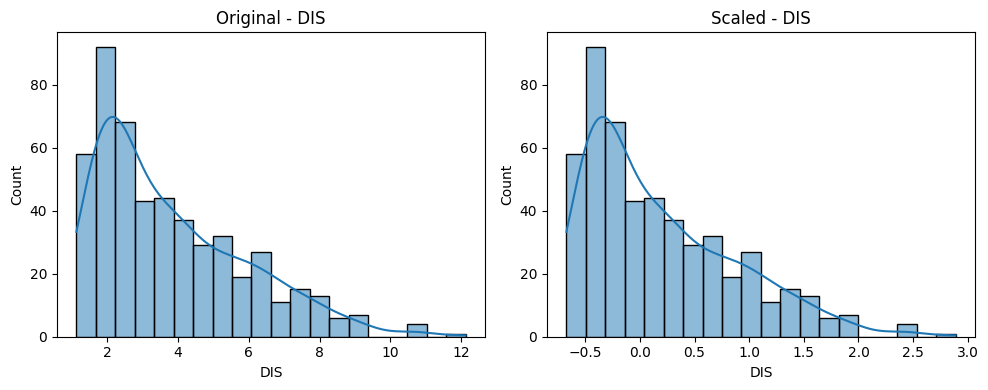

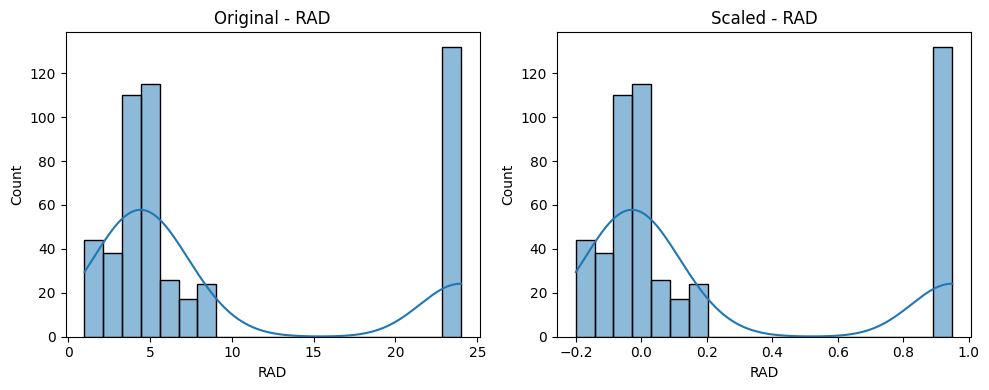

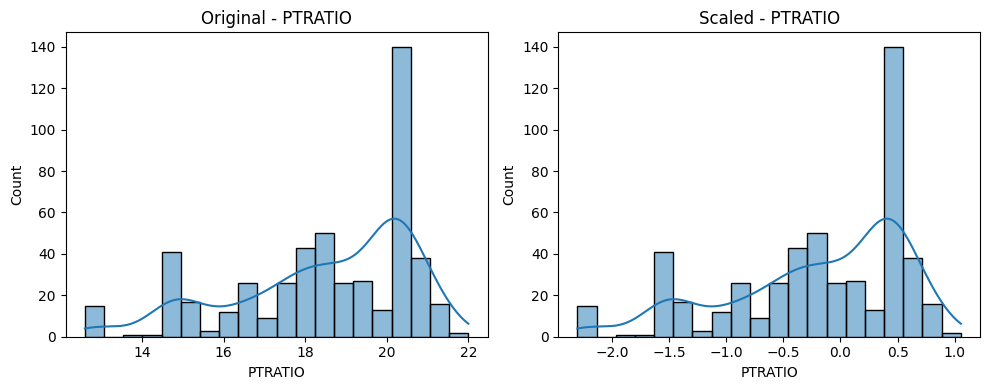

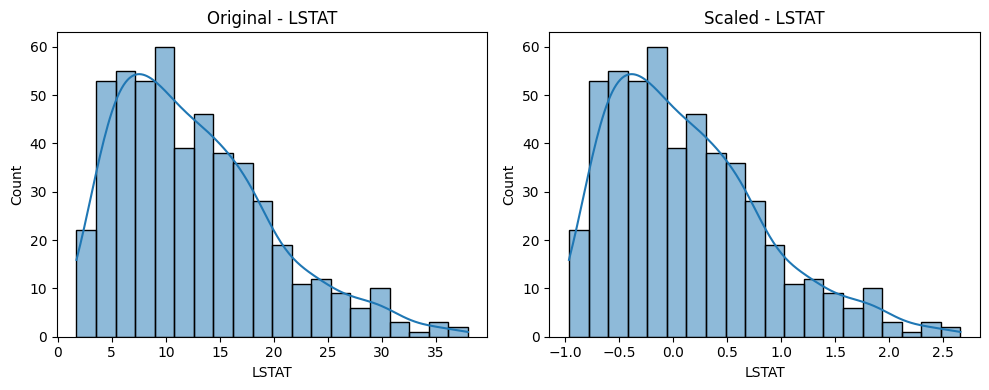

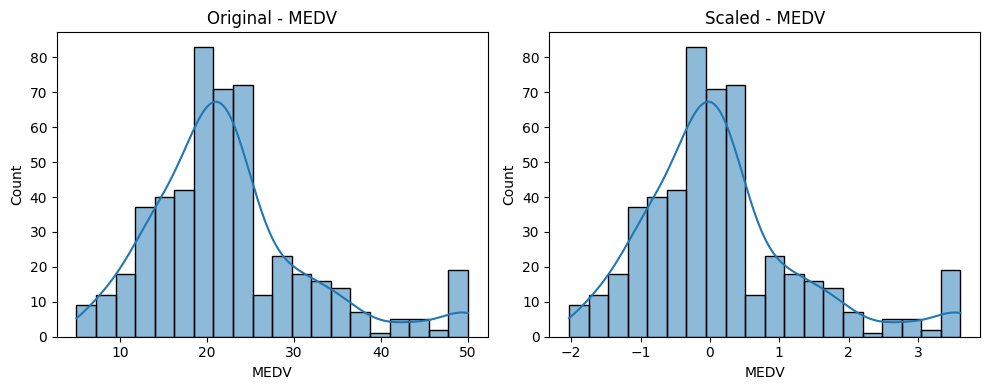

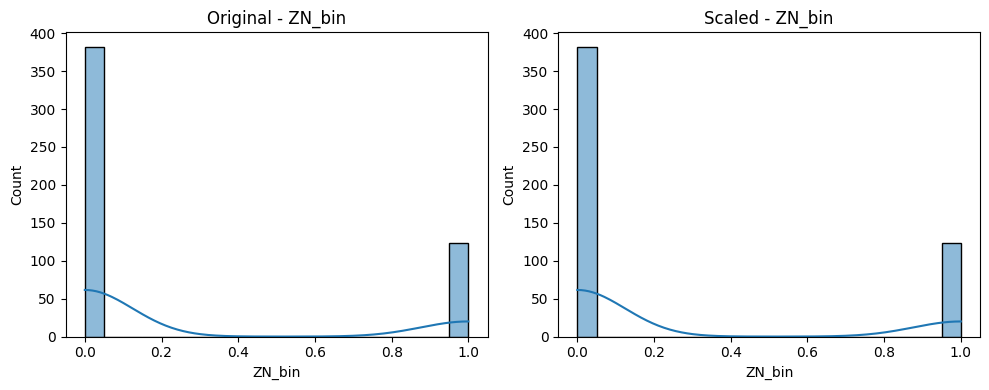

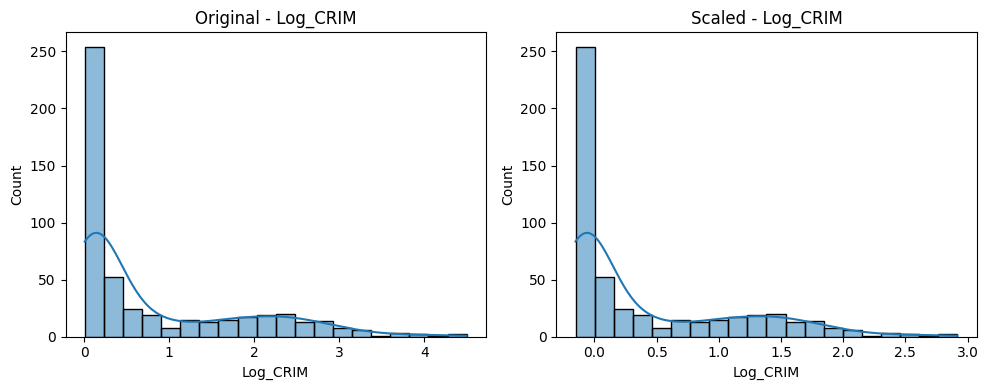

In [ ]:
plt.figure(figsize=(12, 8))


for col in df_scaled.columns:
    plt.figure(figsize=(10, 4))

    # original (left)
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f"Original - {col}")

    # scaled (right)
    plt.subplot(1, 2, 2)
    sns.histplot(df_scaled[col], bins=20, kde=True)
    plt.title(f"Scaled - {col}")

    plt.tight_layout()
    plt.show()

## Not using df_scaled as robustscaling has not changed the shape of histogram for any feature

In [ ]:
## CHAS, RM, PTRATIO, LSTAT, Log_CRIM, DIS- trying capping it with IQR
df_capped = df.copy()
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df_capped[col] = np.where(df[col] > upper, upper,
                       np.where(df[col] < lower, lower, df[col]))

In [ ]:
df_capped

,INDUS,NOX,RM,AGE,DIS,RAD,PTRATIO,LSTAT,MEDV,ZN_bin,Log_CRIM
0,2.31,0.538,6.575,65.2,4.0900,1.0,15.3,4.98,24.0,0.0,0.006300
1,7.07,0.469,6.421,78.9,4.9671,2.0,17.8,9.14,21.6,0.0,0.026944
2,7.07,0.469,7.185,61.1,4.9671,2.0,17.8,4.03,34.7,0.0,0.026924
3,2.18,0.458,6.998,45.8,6.0622,3.0,18.7,2.94,33.4,0.0,0.031857
4,2.18,0.458,7.147,54.2,6.0622,3.0,18.7,5.33,36.2,0.0,0.066770
...,...,...,...,...,...,...,...,...,...,...,...
501,11.93,0.573,6.593,69.1,2.4786,1.0,21.0,9.67,22.4,0.0,0.060747
502,11.93,0.573,6.120,76.7,2.2875,1.0,21.0,9.08,20.6,0.0,0.044275
503,11.93,0.573,6.976,91.0,2.1675,1.0,21.0,5.64,23.9,0.0,0.058986
504,11.93,0.573,6.794,89.3,2.3889,1.0,21.0,6.48,22.0,0.0,0.103991


In [ ]:
outlier_count = {}

for col in df_capped.columns:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count[col] = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()

outlier_count = pd.Series(outlier_count).sort_values(ascending=False)
print("Outlier count per column:\n", outlier_count)

Outlier count per column:
 INDUS       0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
PTRATIO     0
LSTAT       0
MEDV        0
ZN_bin      0
Log_CRIM    0
dtype: int64


## No outlier in df_capped
## Applying model on both- df and df_capped to see the difference

## On df

In [ ]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((379, 11), (127, 11), (379,), (127,))

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Text(0.5, 1.0, 'X_train After scaling')

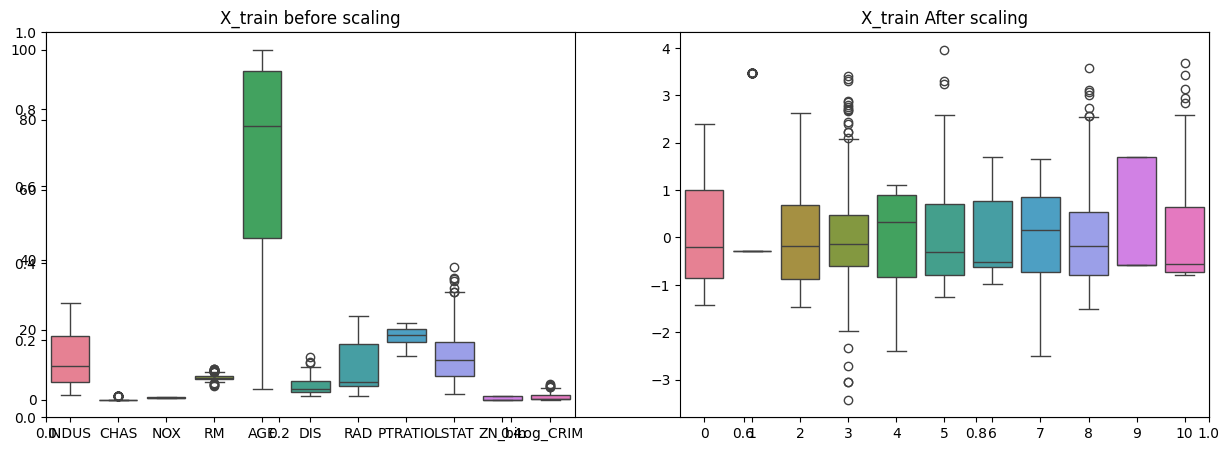

In [ ]:
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title("X_train before scaling")
plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.title("X_train After scaling")

In [ ]:
outlier_count_scaled = []

# Loop through each column (axis=0)
for i in range( X_train_scaled.shape[1]):
    col =  X_train_scaled[:, i]
    Q1 = np.percentile(col, 25)
    Q3 = np.percentile(col, 75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = np.sum((col < lower) | (col > upper))
    outlier_count_scaled.append(count)

outlier_count_scaled = np.array(outlier_count_scaled)
print("Outlier count per column:", outlier_count_scaled)

Outlier count per column: [ 0 29  0 20  0  3  0  0  7  0  5]


In [ ]:
from sklearn.linear_model import LinearRegression
l_r= LinearRegression()
l_r.fit(X_train_scaled, y_train)
y_pred_train = l_r.predict(X_train_scaled)
y_pred_test = l_r.predict(X_test_scaled)
score_scaled = l_r.score(X_test_scaled, y_test)
score_scaled # R2 score

0.6854650745270674

In [ ]:
from sklearn.linear_model import LinearRegression
l_r= LinearRegression()
l_r.fit(X_train, y_train)
y_pred_train = l_r.predict(X_train)
y_pred_test = l_r.predict(X_test)
score_scaled = l_r.score(X_test, y_test)
score_scaled # R2 score

0.6854650745270675

## On df-capped

In [ ]:
X_capped = df_capped.drop("MEDV", axis=1)
y_capped = df_capped["MEDV"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_capped, y_capped, test_size=0.25, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((379, 10), (127, 10), (379,), (127,))

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

Text(0.5, 1.0, 'X_train After scaling')

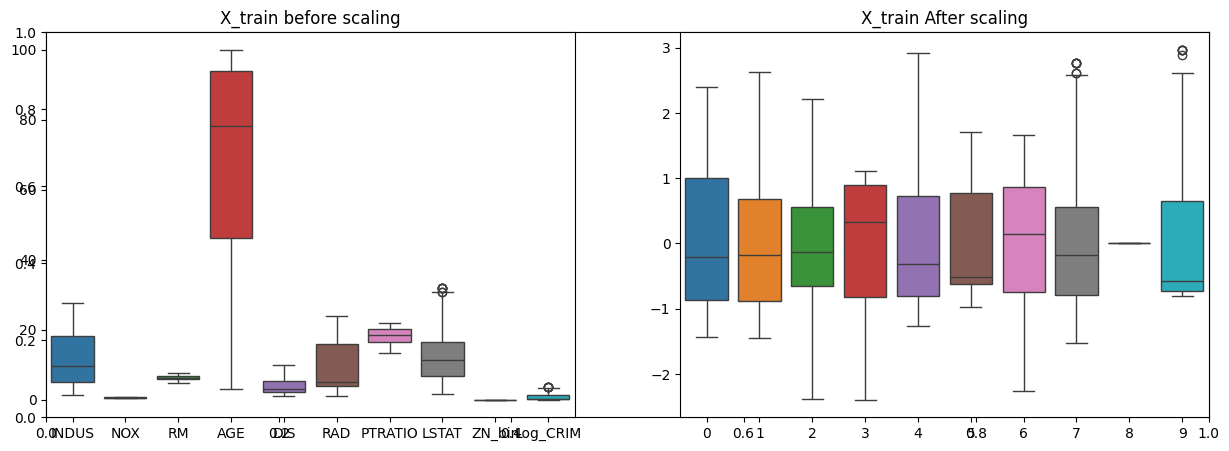

In [ ]:
plt.subplots(figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title("X_train before scaling")
plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.title("X_train After scaling")

In [ ]:
from sklearn.linear_model import LinearRegression
l_r= LinearRegression()
l_r.fit(X_train_scaled, y_train)
y_pred_train = l_r.predict(X_train_scaled)
y_pred_test = l_r.predict(X_test_scaled)
score_scaled = l_r.score(X_test_scaled, y_test)
score_scaled # R2 score

0.745648175606427

## score has improved from 0.68 to 0.74

In [ ]:
l_r.coef_

array([-3.83375556e-01,  1.33226763e-15, -1.28324318e+00,  2.13343191e+00,
       -3.72027178e-01, -2.11315898e+00,  1.27235574e+00, -1.91800218e+00,
       -3.43858264e+00,  0.00000000e+00, -1.94068724e+00])

In [53]:
df_raw = pd.read_csv("BostonHousing.csv")

In [54]:
X_raw = df_raw.drop("MEDV", axis=1)
y_raw = df_raw["MEDV"]

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.25, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((379, 13), (127, 13), (379,), (127,))

In [56]:
from sklearn.linear_model import LinearRegression
l_r= LinearRegression()
l_r.fit(X_train, y_train)
y_pred_train = l_r.predict(X_train)
y_pred_test = l_r.predict(X_test)
score_raw = l_r.score(X_test, y_test)
score_raw # R2 score

0.7986646010097975

## In raw data, linear regression is getting 80% score:😊

In [57]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_pred_test)
rmse

3.754855910388594

In [ ]:
rmse_simple = root_mean_squared_error(y_test, y_pred_test_simple)
rmse_simple

9.006704725081415

## RMSE value for multi linear regression is 3.75 and for simple linear regression it is 9.00.
### as more no. of features used to train the model, the prediction has become accurate in multi linear model